#   Understanding BackPropagation Algorithm Using Sound and Audio Classification

### Student ID =24101661
Github : https://github.com/francischisom/BackPropagation-Algorithm

## Execution Environment

This notebook was developed and executed using Google Colab. The environment provides pre-installed deep learning libraries and allows seamless integration with Google Drive for dataset access.

In [ ]:
# Install required packages in Colab
!pip -q install librosa soundfile

In [ ]:
# Import all the terms needed
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


##  Mount Google Drive and define the dataset path

## Data Loading and Preparation

In this section, metadata CSV files are loaded and combined with their corresponding audio file paths.

Each dataset (heart, lung, and mixed sounds) contains identifiers that are mapped to `.wav` files stored in structured folders.

The file paths are dynamically constructed to ensure flexibility and reproducibility across different environments (local machine or Google Colab).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Set the dataset location in Google Drive
DATA_DIR = Path('/content/drive/MyDrive/ML_project')

required_items = ['HS', 'LS', 'Mix', 'HS.csv', 'LS.csv', 'Mix.csv']



In [ ]:
print("Files and folders inside ML_project:")
for item in sorted(DATA_DIR.iterdir()):
    print("-", item.name)

Files and folders inside ML_project:
- HS
- HS.csv
- LS
- LS.csv
- Mix
- Mix.csv
- cnn_audio_backprop_model.keras


In [ ]:
# print and display the shape of the datasets
hs = pd.read_csv(DATA_DIR / 'HS.csv').copy()
ls = pd.read_csv(DATA_DIR / 'LS.csv').copy()
mix = pd.read_csv(DATA_DIR / 'Mix.csv').copy()

print("HS shape :", hs.shape)
print("LS shape :", ls.shape)
print("Mix shape:", mix.shape)

display(hs.head())
display(ls.head())
display(mix.head())

HS shape : (50, 4)
LS shape : (50, 4)
Mix shape: (145, 7)


,Gender,Heart Sound Type,Location,Heart Sound ID
0,F,Normal,RC,F_N_RC
1,F,Normal,LC,F_N_LC
2,M,Normal,RUSB,M_N_RUSB
3,F,Normal,LUSB,F_N_LUSB
4,F,Normal,LLSB,F_N_LLSB


,Gender,Lung Sound Type,Location,Lung Sound ID
0,M,Normal,RUA,M_N_RUA
1,F,Normal,LUA,F_N_LUA
2,F,Normal,RMA,F_N_RMA
3,F,Normal,LMA,F_N_LMA
4,M,Normal,RLA,M_N_RLA


,Gender,Heart Sound Type,Lung Sound Type,Location,Heart Sound ID,Lung Sound ID,Mixed Sound ID
0,F,Late Systolic Murmur,Rhonchi,LUSB,H0001,L0001,M0001
1,F,S3,Normal,RLA,H0002,L0002,M0002
2,M,Atrial Fibrillation,Normal,LMA,H0003,L0003,M0003
3,F,S3,Coarse Crackles,Apex,H0004,L0004,M0004
4,M,AV Block,Fine Crackles,RUSB,H0005,L0005,M0005


## Audio Feature Extraction: Mel-Spectrogram Generation

This section explains how the raw audio data is transformed into Mel-spectrogram features and fed to the Convolutional Neural Network.

### Parameter Configuration
Several key parameters are defined to control audio processing:

- **Sample Rate (22050 Hz)**: Sample rate at which audio is standardly sampled when opening an .mp3 or similar file.
- **Duration (6 seconds)**: Every audio sample used to train the model will be 6 seconds in duration.
- **Number of Mel Bands (128)**: Controls the frequency resolution of the spectrogram.
- **FFT Window Size (2048)**: Controls frequency resolution during signal transformation.
- **Hop Length (512)**: Defines the step size between successive frames.

### Feature Extraction Process

The `extract_mel_spectrogram` function performs the following steps:

1. ** Audio Loading**
The `.wav` file is loaded using `librosa`, ensuring a consistent sampling rate.

2. ** Length Standardisation**
Audio signals are either:
- **Padded** (if shorter than the target duration), or
- **Trimmed** (if longer),
to maintain a fixed input size across all samples.

3. ** Mel-Spectrogram Computation**
The audio signal is transformed into a Mel-spectrogram, representing the energy distribution of each frequency band over time.

4. ** Log Scaling (Decibel Conversion)**
Spectrogram stretched and converted to decibel scale to match our hearing.

5. ** Normalisation**
Values are scaled to the [0,1] range to improve the stability of the learning process and the numerical stability.

### Output

The function returns a two-dimensional NumPy array representing the Mel-spectrogram.

Sample extraction to prove transformation happening and shape is what we expect for the input to our CNN.

In [ ]:
# Audio feature settings
SAMPLE_RATE = 22050
DURATION = 6
N_MELS = 128
N_FFT = 2048
HOP_LENGTH = 512

def extract_mel_spectrogram(
    file_path: str,
    sr: int = SAMPLE_RATE,
    duration: int = DURATION,
    n_mels: int = N_MELS,
    n_fft: int = N_FFT,
    hop_length: int = HOP_LENGTH,
) -> np.ndarray:
    """Load an audio file and convert it to a fixed-size Mel-spectrogram."""
    audio, sample_rate = librosa.load(file_path, sr=sr)

    target_length = sr * duration
    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)))
    else:
        audio = audio[:target_length]

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sample_rate,
        n_mels=n_mels,
        n_fft=n_fft,
        hop_length=hop_length,
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Normalise to [0, 1]
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)

    return mel_db.astype(np.float32)

# Helper function to create the unified audio_df
def create_audio_df(hs_df, ls_df, mix_df, data_dir):
    all_audio_data = []

    # Process Heart Sounds
    heart_data = hs_df.copy()
    heart_data['filepath'] = heart_data['Heart Sound ID'].apply(lambda x: data_dir / 'HS' / f"{x}.wav")
    heart_data['label'] = 'heart'
    all_audio_data.append(heart_data[['filepath', 'label']])

    # Process Lung Sounds
    lung_data = ls_df.copy()
    lung_data['filepath'] = lung_data['Lung Sound ID'].apply(lambda x: data_dir / 'LS' / f"{x}.wav")
    lung_data['label'] = 'lung'
    all_audio_data.append(lung_data[['filepath', 'label']])

    # Process Mixed Sounds
    # Assuming mixed audio files are named using 'Heart Sound ID' in the 'Mix' folder.
    mixed_data = mix_df.copy()
    mixed_data['filepath'] = mixed_data['Heart Sound ID'].apply(lambda x: data_dir / 'Mix' / f"{x}.wav")
    mixed_data['label'] = 'mixed'
    all_audio_data.append(mixed_data[['filepath', 'label']])

    combined_df = pd.concat(all_audio_data, ignore_index=True)
    combined_df['file_exists'] = combined_df['filepath'].apply(lambda x: x.exists())
    return combined_df

# Create the audio_df DataFrame
audio_df = create_audio_df(hs, ls, mix, DATA_DIR)

print("Audio DataFrame head:")
display(audio_df.head())
print("\nMissing files check:")
print(audio_df['file_exists'].value_counts())




Audio DataFrame head:


,filepath,label,file_exists
0,/content/drive/MyDrive/ML_project/HS/F_N_RC.wav,heart,True
1,/content/drive/MyDrive/ML_project/HS/F_N_LC.wav,heart,True
2,/content/drive/MyDrive/ML_project/HS/M_N_RUSB.wav,heart,True
3,/content/drive/MyDrive/ML_project/HS/F_N_LUSB.wav,heart,True
4,/content/drive/MyDrive/ML_project/HS/F_N_LLSB.wav,heart,True



Missing files check:
file_exists
True     230
False     15
Name: count, dtype: int64


## Feature Matrix Construction and Label Encoding

The process of converting the data after processing into the format required to train the Convolutional Neural Network.

### Data Filtering

Only valid audio samples are kept after filtering out rows where the file exists. This ensures that the feature extraction is only run on audio files that exist and are properly linked.

### Feature Matrix (X)

Mel-spectrogram features are generated for each audio file using the prepare_features() function defined above and stored in a NumPy array:

- Each sample is represented as a two-dimensional Mel-spectrogram.
- An additional channel dimension is introduced to match the input shape expected by the CNNs. This results in a 3D input for each sample.

### Target Labels (y)

Next up, we'll be using label encoding to transform the categorical labels in our data into something the model can work with (i.e., into numbers). We've already established that our data is categorical (i.e., heart, lung, or mixed), and machine learning algorithms need numbers to make a classification decision.

### Output Verification

We print the shapes of our X and y:
- The number of samples
- The dimensionality of the input features
- The number of output classes

This step is about data preparation in order to ensure that the data is suitable for modeling.

In [ ]:
# Filter dataset to keep only rows where audio files exist
audio_df_filtered = audio_df[audio_df['file_exists']].copy()

# Generate Mel-spectrogram features for each audio file
X = np.array([
    extract_mel_spectrogram(fp)
    for fp in audio_df_filtered['filepath']
])

# Add channel dimension (required for CNN input: height x width x channels)
X = X[..., np.newaxis]

# Encode categorical labels into numerical values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(audio_df_filtered['label'])



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)

Train shape: (184, 128, 259, 1) (184,)
Test shape : (46, 128, 259, 1) (46,)


## Model Construction and Training Workflow

The Convolutional Neural Network must first be defined and compiled before training can occur.

The model architecture specifies how input data flows through the network, while compilation defines the learning process, including the loss function and optimisation algorithm.

Training is then performed using backpropagation, where prediction errors are propagated backward through the network to update model weights iteratively.

In [ ]:
model = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 257, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 128, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 126, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 53760)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,881,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,974,467 (26.61 MB)

 Trainable params: 6,974,467 (26.61 MB)

 Non-trainable params: 0 (0.00 B)

## Model Training with Early Stopping

This section shows the training of the Convolutional Neural Network with the dataset we prepared. The training involves the optimisation of the model parameters via backpropagation over multiple iterations.

### Early Stopping

To make the model generalize better and to prevent overfitting, an early stopping mechanism is used. Early stopping checks the validation loss over time and stops training if validation loss has not improved for a given number of epochs.

- **monitor='val_loss'**: Tracks the validation loss
- **patience=5**: Training stops if no improvement occurs for 5 consecutive epochs
- **restore_best_weights=True**: Ensures the model retains the best-performing weights

### Training Process
Backpropagation occurs inside `model.fit(...)`:
The model is trained using:
- A validation split of 20% to evaluate performance during training
- A batch size of 16 for efficient gradient updates
- A maximum of 10 epochs

During each epoch:
1. A forward pass generates predictions
2. The loss function computes prediction error
3. Backpropagation calculates gradients
4. The optimizer updates model weights

Stochastic gradient descent is an optimization process that helps train a model by reducing its error over time and increasing the accuracy of its classifications.

In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.5782 - loss: 0.9910 - val_accuracy: 0.7027 - val_loss: 0.7934
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6122 - loss: 0.9289 - val_accuracy: 0.7027 - val_loss: 0.7992
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.6122 - loss: 0.8678 - val_accuracy: 0.7027 - val_loss: 0.7423
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.6122 - loss: 0.7717 - val_accuracy: 0.7297 - val_loss: 0.6646
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7007 - loss: 0.7535 - val_accuracy: 0.5946 - val_loss: 0.7356
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.6463 - loss: 0.6786 - val_accuracy: 0.8108 - val_loss: 0.6625
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 29s 2s/step - accuracy: 0.7347 - loss: 0.5910 - val_accuracy: 0.5676 - val_loss: 0.7082
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7619 - loss: 0.5461 - val_accuracy: 0.5676 - val_loss:

## Backpropagation Demonstration (Gradient Computation)

Here the backpropagation process is illustrated using a sample batch of training data.

The forward pass is performed to get predictions and the loss. Then gradients of the loss with respect to the model parameters are calculated during the backward pass using GradientTape from TensorFlow.

The gradients show how each parameter contributes to the error and are used by the optimizer to compute the updates of the model weights.

In [ ]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
optimizer = tf.keras.optimizers.Adam()

x_batch = tf.convert_to_tensor(X_train[:16])
y_batch = tf.convert_to_tensor(y_train[:16])

with tf.GradientTape() as tape:
    predictions = model(x_batch, training=True)      # Forward pass
    loss_value = loss_fn(y_batch, predictions)       # Loss calculation

gradients = tape.gradient(loss_value, model.trainable_variables)  # Backward pass

print("Loss on batch:", float(loss_value.numpy()))
print("Number of trainable tensors:", len(model.trainable_variables))
print("Number of gradient tensors :", len(gradients))

for i, grad in enumerate(gradients[:5]):
    print(f"Gradient {i+1} shape:", grad.shape if grad is not None else None)

Loss on batch: 0.49190255999565125
Number of trainable tensors: 10
Number of gradient tensors : 10
Gradient 1 shape: (3, 3, 1, 32)
Gradient 2 shape: (32,)
Gradient 3 shape: (3, 3, 32, 64)
Gradient 4 shape: (64,)
Gradient 5 shape: (3, 3, 64, 128)


## Model Performance Evaluation

This section evaluates the model on test dataset to see how it performs on unseen data.

### Test Evaluation

The model computes:
- **Test loss**: Measures the overall prediction error
- **Test accuracy**: Indicates the proportion of correctly classified samples

These metrics provide a high-level assessment of model performance.

### Prediction and Classification

The model outputs a vector of probabilities representing the model’s estimated probability of being in each class. The probabilities are then transformed to class labels by selecting the class with the highest estimated probability.

### Classification Report

A detailed classification report is produced, including:
- **Precision**: Accuracy of positive predictions
- **Recall**: Ability to identify all relevant instances
- **F1-score**: Harmonic mean of precision and recall

The overall performance of each class and whether there is class imbalance or misclassification can be gain insight by examining the classification performance for each class.

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss    : {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

y_prob = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Test loss    : 0.7004
Test accuracy: 0.7826
              precision    recall  f1-score   support

       heart       0.00      0.00      0.00        10
        lung       1.00      1.00      1.00         7
       mixed       0.74      1.00      0.85        29

    accuracy                           0.78        46
   macro avg       0.58      0.67      0.62        46
weighted avg       0.62      0.78      0.69        46



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Training Performance Visualisation

This plot gives a sense of how the model is learning over the training process.

### Accuracy Curve

Training and validation accuracy as a function of the epoch number.

- **Training accuracy** reflects performance on the training dataset
- **Validation accuracy** reflects performance on unseen validation data

Both validation and training set measures of accuracy should be increasing as the model learns. The gap between these two values should not be becoming too large, as this would indicate overfitting.

### Loss Curve

The loss for training and validation is also plotted to see how the error at making predictions changes during training.

- Decreasing loss indicates that the model is improving
- Divergence between training and validation loss may indicate overfitting

### Interpretation

These plots provide insight into:
- Model convergence
- Generalisation performance
- Potential overfitting or underfitting

They are essential for diagnosing the effectiveness of the training process.## 14. Plot training curves

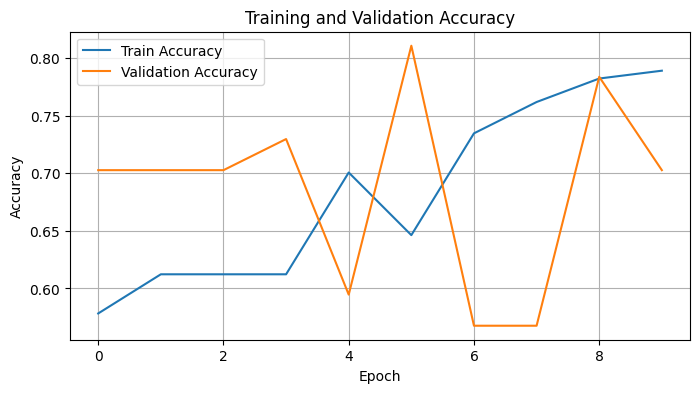

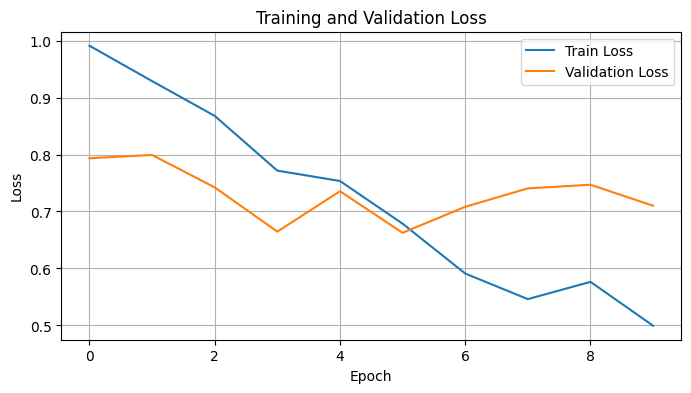

In [ ]:
# Plot accuracy over epochs
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.savefig('accuracy_curve.png')
plt.show()

# Plot loss over epochs
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png')
plt.show()

##
Confusion matrix

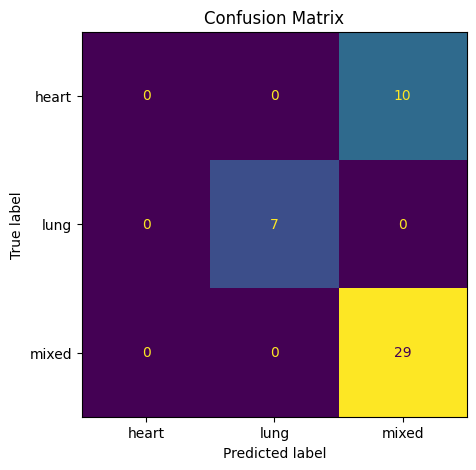

In [ ]:
# Compute confusion matrix comparing true vs predicted labels
cm = confusion_matrix(y_test, y_pred)

# Create a display object with class labels
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False)

# Add title for clarity
plt.title('Confusion Matrix')

plt.savefig('confusion_matrix.png')
# Display plot
plt.show()

## Conclusion

In this project, I trained a Convolutional Neural Network (CNN) classifier using the backpropagation algorithm to classify audio signals. I went into great detail in the preprocessing part of the project, and I realized that the audio signals have to be converted into Mel-spectrogram format so that the network can learn the patterns in the time-frequency domain of different sounds and classify the audio signals into heart, lung and mixed sounds accordingly.

Backpropagation is a mechanism used to compute the errors of the prediction made by a neural network. Training aims at explaining this mechanism in detail and how errors are propagated backwards in order to compute the gradients. After computing the errors, we update the model parameters to train the model. Finally, we make use of the Adam optimizer in order to minimize the loss function and get the highest possible accuracy.

The evaluation metrics, classification report and confusion matrix summarised the findings of the evaluation. The metrics showed that the proposed model was able to classify the audio classes correctly and that misclassifications were a result of similar acoustic features in the classes.

The early stopping scheme was used to prevent overfitting and to ensure that the model with the optimal set of weights for the validation set was selected. The training and validation curves are shown below and are used to assess the learning of the model.

In general the project demonstrates the importance of backpropagation for deep neural networks. It demonstrates the capabilities of signal processing and deep learning for audio processing classification problems.

Future work might include the expansion of the training set, data augmentation and the use of a more complex model.